# 07. Week 7 - Clustering and Validation Report

    Objective: segment the anime catalog and validate whether the segmentation is meaningful. The clustering representation is based on the Week 5 mixed feature design.

In [1]:
from pathlib import Path
import os
from collections import Counter
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
BUILD_DIR = DATA_DIR / "build"
PLOT_DIR = BASE_DIR / "artifacts" / "plots"

ANIME_PATH = PROCESSED_DIR / "anime_dataset.csv"
RATINGS_PATH = PROCESSED_DIR / "ratings_processed.csv"

def split_pipe(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [part.strip() for part in str(value).split("|") if part.strip()]

def count_pipe(value):
    return len(split_pipe(value))

def explode_pipe_counts(series):
    counts = Counter()
    for value in series.dropna():
        counts.update(split_pipe(value))
    return pd.DataFrame(counts.most_common(), columns=["value", "count"])

def parse_duration_minutes(value):
    if pd.isna(value) or str(value).strip() == "":
        return np.nan
    if isinstance(value, (int, float)) and not pd.isna(value):
        return float(value) if float(value) > 0 else np.nan

    text = str(value).strip().lower()
    if re.fullmatch(r"\d+(?:\.\d+)?", text):
        numeric = float(text)
        return numeric if numeric > 0 else np.nan

    hours = re.search(r"(\d+(?:\.\d+)?)\s*(?:hr|hour)", text)
    minutes = re.search(r"(\d+(?:\.\d+)?)\s*min", text)
    seconds = re.search(r"(\d+(?:\.\d+)?)\s*sec", text)
    total = 0.0
    if hours:
        total += float(hours.group(1)) * 60
    if minutes:
        total += float(minutes.group(1))
    if seconds:
        total += float(seconds.group(1)) / 60
    return total if total > 0 else np.nan

def infer_season(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [1, 2, 3]:
        return "winter"
    if month in [4, 5, 6]:
        return "spring"
    if month in [7, 8, 9]:
        return "summer"
    if month in [10, 11, 12]:
        return "fall"
    return np.nan

def add_bar_labels(ax, fmt="{:.0f}"):
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width, patch.get_y() + patch.get_height() / 2, " " + fmt.format(width), va="center", fontsize=9)

def save_current_plot(path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")

from scipy import sparse
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

WEEK7_PLOT_DIR = PLOT_DIR / "week7"
WEEK7_PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ANIME_PATH)
df = df.rename(columns={"explicit_genres": "explicit_tags", "explicit_genre_weights": "explicit_tag_weights"})
df["duration_minutes"] = df["duration"].apply(parse_duration_minutes)
df["season_final"] = df["season"].fillna(df["aired_month"].apply(infer_season))
df["total_watch_minutes"] = df["episodes"] * df["duration_minutes"]

for col in ["genres", "tags", "explicit_tags", "demographics", "studios", "synopsis", "season_final", "type", "rating"]:
    if col not in df:
        df[col] = ""
    df[col] = df[col].fillna("")

df.shape


(16664, 34)

## Representation Chosen for Clustering

    We cluster a reduced SVD representation of numeric, categorical, and text/tag features. This is more defensible than clustering t-SNE coordinates because SVD is a linear compression of the actual feature matrix, while t-SNE is mainly visualization-oriented and can create visual islands that are not stable clusters.

In [2]:
numeric_cols = ["score", "scored_by", "rank", "popularity", "members", "favorites", "episodes", "duration_minutes", "total_watch_minutes", "aired_year", "aired_month"]
numeric_cols = [col for col in numeric_cols if col in df.columns]
X_numeric = sparse.csr_matrix(StandardScaler().fit_transform(df[numeric_cols].fillna(0)))

cat_specs = {
    "genres": df["genres"].apply(split_pipe).tolist(),
    "demographics": df["demographics"].apply(split_pipe).tolist(),
    "type": df["type"].apply(lambda x: [x] if x else []).tolist(),
    "rating": df["rating"].apply(lambda x: [x] if x else []).tolist(),
    "season": df["season_final"].apply(lambda x: [x] if x else []).tolist(),
}
cat_mats = []
for name, values in cat_specs.items():
    mlb = MultiLabelBinarizer()
    cat_mats.append(sparse.csr_matrix(mlb.fit_transform(values)))
X_cat = sparse.hstack(cat_mats, format="csr")

text = df["synopsis"] + " " + df["genres"] + " " + df["tags"] + " " + df["explicit_tags"] + " " + df["studios"] + " " + df["demographics"]
X_text = TfidfVectorizer(max_features=3500, min_df=3, max_df=0.85, stop_words="english").fit_transform(text)

X_full = sparse.hstack([X_numeric, X_cat, X_text], format="csr")
svd = TruncatedSVD(n_components=50, random_state=42)
X_cluster = svd.fit_transform(X_full)
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

print("Full feature matrix:", X_full.shape)
print("Clustering matrix:", X_cluster_scaled.shape)
print("SVD retained variance:", round(float(svd.explained_variance_ratio_.sum()), 4))

Full feature matrix: (16664, 3554)
Clustering matrix: (16664, 50)
SVD retained variance: 0.9456


## K-means Parameter Sweep

    K-means assumes roughly spherical clusters in Euclidean space and forces every anime into one segment. We sweep K instead of hand-picking a single result.

In [3]:
k_values = list(range(4, 21, 2))
kmeans_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, labels, sample_size=min(5000, len(labels)), random_state=42)
    db = davies_bouldin_score(X_cluster_scaled, labels)
    kmeans_rows.append({"method": "KMeans", "k": k, "silhouette": sil, "davies_bouldin": db, "inertia": model.inertia_})

kmeans_results = pd.DataFrame(kmeans_rows)
kmeans_results

,method,k,silhouette,davies_bouldin,inertia
0,KMeans,4,0.057001,3.932817,780172.816469
1,KMeans,6,0.028989,3.699124,748353.918886
2,KMeans,8,0.050449,3.350319,716880.551969
3,KMeans,10,0.051253,2.890972,685516.674716
4,KMeans,12,0.073493,2.840132,664545.431854
5,KMeans,14,0.057036,2.592509,641766.324255
6,KMeans,16,0.082976,2.478919,618528.079284
7,KMeans,18,0.075784,2.422624,597438.585938
8,KMeans,20,0.104147,2.389221,576681.686488


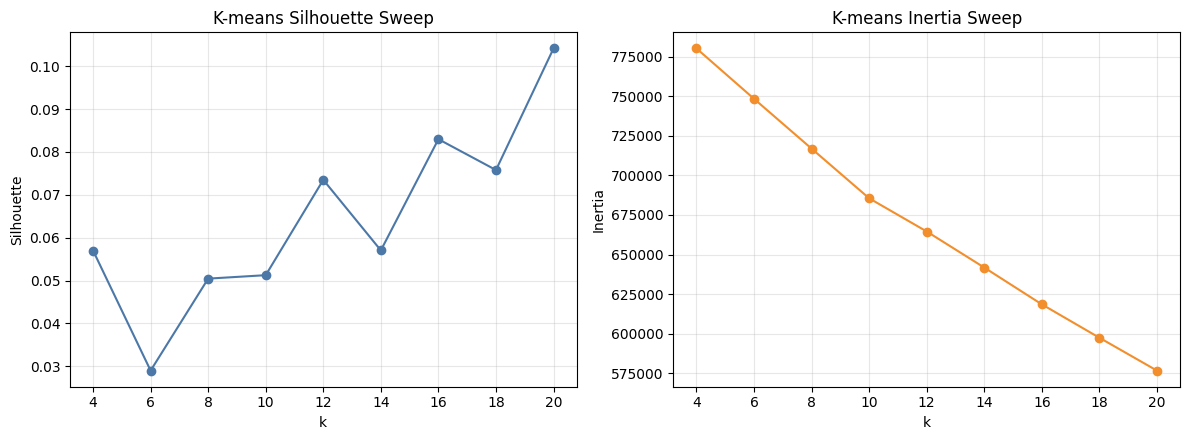

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o", color="#4C78A8")
axes[0].set_title("K-means Silhouette Sweep")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")
axes[0].grid(alpha=0.3)
axes[1].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o", color="#F28E2B")
axes[1].set_title("K-means Inertia Sweep")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")
axes[1].grid(alpha=0.3)
save_current_plot(WEEK7_PLOT_DIR / "kmeans_parameter_sweep.png")
plt.show()

## DBSCAN Parameter Sweep

    DBSCAN is a density method. It can label outliers as noise, which is useful because anime metadata includes unusual shorts, specials, adult entries, and edge-case formats. The tradeoff is sensitivity to `eps` and `min_samples`.

In [5]:
dbscan_rows = []
sample_n = min(6000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=sample_n, replace=False)
X_db = X_cluster_scaled[sample_idx]

for eps in [1.8, 2.2, 2.6, 3.0, 3.4, 3.8]:
    for min_samples in [10, 20, 35]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_db)
        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = float((labels == -1).mean() * 100)
        if clusters >= 2 and (labels != -1).sum() > clusters:
            sil = silhouette_score(X_db[labels != -1], labels[labels != -1])
        else:
            sil = np.nan
        dbscan_rows.append({"method": "DBSCAN", "eps": eps, "min_samples": min_samples, "clusters": clusters, "noise_pct": noise_pct, "silhouette_non_noise": sil})

dbscan_results = pd.DataFrame(dbscan_rows)
dbscan_results

,method,eps,min_samples,clusters,noise_pct,silhouette_non_noise
0,DBSCAN,1.8,10,9,90.633333,0.350517
1,DBSCAN,1.8,20,5,92.250000,0.326968
2,DBSCAN,1.8,35,4,96.816667,0.380498
3,DBSCAN,2.2,10,16,88.950000,0.339441
4,DBSCAN,2.2,20,5,91.266667,0.297495
5,DBSCAN,2.2,35,5,92.050000,0.321278
6,DBSCAN,2.6,10,27,86.366667,0.318851
7,DBSCAN,2.6,20,6,90.816667,0.308911
8,DBSCAN,2.6,35,5,91.383333,0.305659
9,DBSCAN,3.0,10,15,82.533333,0.309193


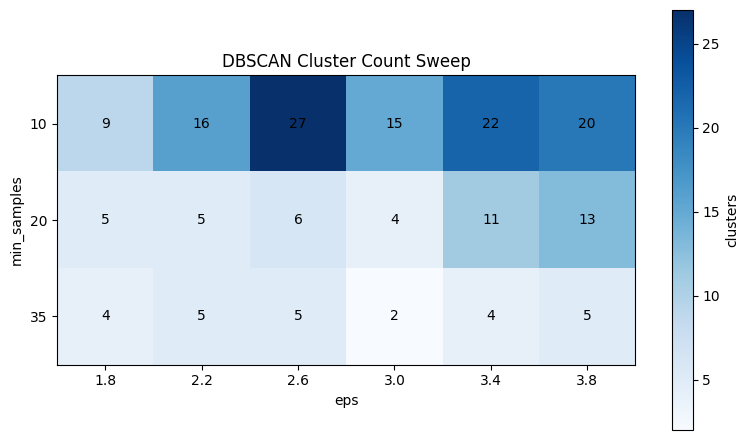

In [6]:
pivot = dbscan_results.pivot(index="min_samples", columns="eps", values="clusters")
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(pivot.values, cmap="Blues")
ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns)
ax.set_yticks(range(len(pivot.index)), labels=pivot.index)
ax.set_xlabel("eps")
ax.set_ylabel("min_samples")
ax.set_title("DBSCAN Cluster Count Sweep")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, int(pivot.values[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="clusters")
save_current_plot(WEEK7_PLOT_DIR / "dbscan_parameter_sweep.png")
plt.show()

## OPTICS Density Sweep

    OPTICS is a second density-based method. It is useful here because it does not require one global `eps` choice in the same way as DBSCAN; it orders points by reachability and can expose variable-density structure. This is still exploratory and is run on the same sample used for DBSCAN.


In [7]:
optics_rows = []
for min_samples in [10, 20, 35, 50]:
    for xi in [0.03, 0.05, 0.08]:
        model = OPTICS(min_samples=min_samples, xi=xi, min_cluster_size=0.01, n_jobs=-1)
        labels = model.fit_predict(X_db)
        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = float((labels == -1).mean() * 100)
        if clusters >= 2 and (labels != -1).sum() > clusters:
            sil = silhouette_score(X_db[labels != -1], labels[labels != -1])
        else:
            sil = np.nan
        optics_rows.append({
            "method": "OPTICS",
            "min_samples": min_samples,
            "xi": xi,
            "clusters": clusters,
            "noise_pct": noise_pct,
            "silhouette_non_noise": sil,
        })

optics_results = pd.DataFrame(optics_rows)
optics_results


,method,min_samples,xi,clusters,noise_pct,silhouette_non_noise
0,OPTICS,10,0.03,8,89.116667,0.287817
1,OPTICS,10,0.05,7,88.833333,0.280637
2,OPTICS,10,0.08,5,91.116667,0.292307
3,OPTICS,20,0.03,6,89.150000,0.282050
4,OPTICS,20,0.05,5,90.983333,0.292006
5,OPTICS,20,0.08,4,92.150000,0.248482
6,OPTICS,35,0.03,5,90.650000,0.297143
7,OPTICS,35,0.05,5,90.716667,0.297366
8,OPTICS,35,0.08,1,97.983333,NaN
9,OPTICS,50,0.03,5,90.983333,0.308662


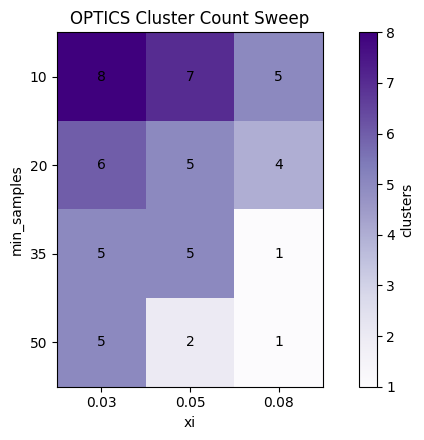

In [8]:
pivot = optics_results.pivot(index="min_samples", columns="xi", values="clusters")
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(pivot.values, cmap="Purples")
ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns)
ax.set_yticks(range(len(pivot.index)), labels=pivot.index)
ax.set_xlabel("xi")
ax.set_ylabel("min_samples")
ax.set_title("OPTICS Cluster Count Sweep")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, int(pivot.values[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="clusters")
save_current_plot(WEEK7_PLOT_DIR / "optics_parameter_sweep.png")
plt.show()


## Cluster Selection and Profiles

    We select a K-means model using the sweep and then profile clusters with domain fields. A cluster is useful only if it can be interpreted operationally, not merely because a metric is high.

In [9]:
best_k = int(kmeans_results.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["k"])
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster"] = best_model.fit_predict(X_cluster_scaled)

cluster_summary = (
    df.groupby("cluster")
    .agg(
        anime_count=("mal_id", "size"),
        mean_score=("score", "mean"),
        median_members=("members", "median"),
        mean_episodes=("episodes", "mean"),
        relation_rows=("relations", lambda s: s.notna().sum()),
        recommendation_rows=("recommendations", lambda s: s.notna().sum()),
    )
    .sort_values("anime_count", ascending=False)
)
cluster_summary

,anime_count,mean_score,median_members,mean_episodes,relation_rows,recommendation_rows
cluster,,,,,,
5,2421,6.408397,6375.0,10.885171,1189,1304
7,1681,7.142219,41821.0,17.161808,1238,1144
1,1589,6.222379,5630.0,7.594714,336,837
2,1574,6.131989,2035.0,11.486658,721,582
11,1394,7.018874,43812.5,10.360832,952,1088
4,1144,6.686372,3492.0,19.565559,657,558
19,1012,6.429694,6179.0,2.857708,751,513
14,918,6.340414,1991.0,21.270153,563,321
3,837,6.095042,913.0,18.475508,396,278


In [10]:
def top_values_by_cluster(cluster_id, column, n=8):
    values = Counter()
    subset = df[df["cluster"] == cluster_id]
    for value in subset[column].dropna():
        values.update(split_pipe(value))
    return ", ".join([f"{key} ({count})" for key, count in values.most_common(n)])

profile_rows = []
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    examples = subset.sort_values("members", ascending=False)["title"].head(5).tolist()
    profile_rows.append({
        "cluster": cluster_id,
        "anime_count": len(subset),
        "top_genres": top_values_by_cluster(cluster_id, "genres"),
        "top_tags": top_values_by_cluster(cluster_id, "tags"),
        "top_demographics": top_values_by_cluster(cluster_id, "demographics"),
        "popular_examples": " | ".join(examples),
    })
cluster_profiles = pd.DataFrame(profile_rows).sort_values("anime_count", ascending=False)
cluster_profiles

,cluster,anime_count,top_genres,top_tags,top_demographics,popular_examples
5,5,2421,"Comedy (885), Sci-Fi (583), Action (542), Fantasy (503), Drama (453), Romance (333), Supernatural (173), Mystery (142)","speculative fiction (906), cast (666), action (637), comedy (636), science fiction (562), romance (460), fantasy (447), tropes (397)",Josei (83),ReLIFE | Golden Time | Wotaku ni Koi wa Muzukashii | Youjo Senki | The God of High School
7,7,1681,"Action (837), Comedy (757), Adventure (623), Fantasy (544), Sci-Fi (418), Romance (282), Drama (211), Supernatural (206)","action (1000), speculative fiction (992), comedy (867), cast (671), fantasy (650), violence (552), tropes (535), science fiction (533)","Shounen (1681), Josei (1)",Noragami | Ansatsu Kyoushitsu | Ao no Exorcist | Dr. Stone | Boku no Hero Academia 4th Season
1,1,1589,"Hentai (1583), Fantasy (90), Supernatural (68), Comedy (60), Action (35), Horror (30), Sci-Fi (30), Drama (27)","cast (566), romance (489), speculative fiction (400), school life (376), fantasy (303), comedy (283), infidelity (275), storytelling (268)","18+ (1583), Josei (12), Seinen (2), Shounen (1), Kodomo (1)",Meitantei Conan | Overflow | Crayon Shin-chan | Euphoria | A Kite
2,2,1574,"Comedy (754), Fantasy (420), Action (411), Sci-Fi (271), Romance (163), Drama (152), Supernatural (125), Ecchi (103)","speculative fiction (323), comedy (251), action (239), cast (231), science fiction (179), fantasy (178), romance (163), Historical (159)","18+ (237), Shounen (65), Josei (5)",High School DxD New | Shimoneta to Iu Gainen ga Sonzai Shinai Taikutsu na Sekai | High School DxD BorN | NHK ni Youkoso! | Strike the Blood
11,11,1394,"Comedy (642), Action (514), Drama (357), Romance (328), Sci-Fi (306), Fantasy (280), Adventure (266), Mystery (178)","comedy (827), speculative fiction (808), cast (804), action (737), romance (655), tropes (574), violence (561), fantasy (539)","Seinen (1394), Shounen (92), Josei (3), 18+ (1)",Violet Evergarden | One Punch Man 2nd Season | Kill la Kill | Another | Tate no Yuusha no Nariagari
4,4,1144,"Adventure (1144), Fantasy (654), Action (605), Sci-Fi (270), Comedy (246), Drama (155), Romance (107), Mystery (49)","speculative fiction (522), action (428), fantasy (308), Historical (297), science fiction (293), comedy (248), Martial Arts (248), cast (235)","18+ (46), Josei (4)",Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka | Mushoku Tensei: Isekai Ittara Honki Dasu | Ore dake Level Up na Ken | Mushoku Tensei: Isekai Itta...
19,19,1012,"Comedy (634), Action (202), Sci-Fi (188), Fantasy (140), Romance (116), Adventure (115), Drama (94), Ecchi (85)","comedy (482), speculative fiction (476), cast (451), action (424), tropes (368), romance (364), fantasy (289), science fiction (281)","Seinen (279), Shounen (255), 18+ (35), Josei (15)","Steins;Gate: Oukoubakko no Poriomania | ReLIFE: Kanketsu-hen | Violet Evergarden: Kitto ""Ai"" wo Shiru Hi ga Kuru no Darou | One Punch Man Specials | Sword A..."
14,14,918,"Comedy (481), Adventure (406), Fantasy (402), Action (177), Sci-Fi (175), Drama (63), Mystery (28), Supernatural (22)","speculative fiction (306), comedy (194), fantasy (185), action (184), science fiction (159), adventure (116), Mecha (85), proxy battles (79)","Kodomo (838), Shounen (167), Seinen (16), Josei (1)",Pokemon | Digimon Adventure | Tonari no Seki-kun | Pokemon: The Origin | Digimon Adventure 02
3,3,837,"Comedy (281), Fantasy (268), Adventure (219), Drama (96), Action (67), Sci-Fi (53), Supernatural (31), Romance (14)","comedy (177), speculative fiction (172), fantasy (126), adventure (115), anthropomorphism (95), action (82), daily life (80), Historical (72)","Kodomo (837), Shounen (41), Seinen (6), Josei (2)","Hotaru no Haka | Ged Senki | Gyakuten Saiban: Sono ""Shinjitsu"", Igi Ari! | Mary to Majo no Hana | Interstella5555: The 5tory of The 5ecret 5tar 5ystem"
0,0,729,"Slice of Life (729), Fantasy (75), Supernatural (55), Adventure (47), Sci-Fi (37), Mystery

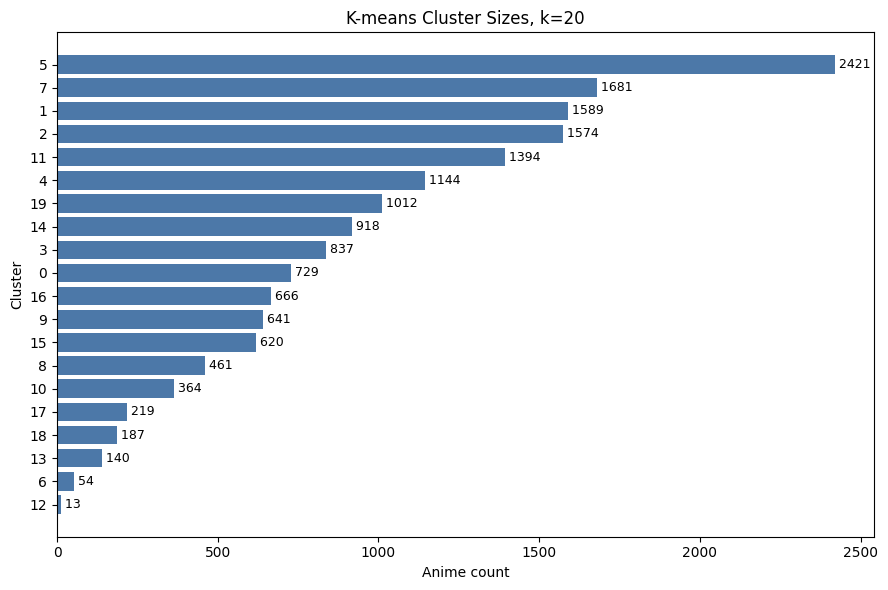

In [11]:
plot_df = cluster_summary.reset_index().sort_values("anime_count")
fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.3)))
ax.barh(plot_df["cluster"].astype(str), plot_df["anime_count"], color="#4C78A8")
ax.set_title(f"K-means Cluster Sizes, k={best_k}")
ax.set_xlabel("Anime count")
ax.set_ylabel("Cluster")
add_bar_labels(ax)
save_current_plot(WEEK7_PLOT_DIR / "kmeans_cluster_sizes.png")
plt.show()

### Cluster Visualization

    These plots connect metric validation back to the representation. The scatter uses the same SVD space used for clustering; the heatmap checks whether clusters have interpretable genre profiles.


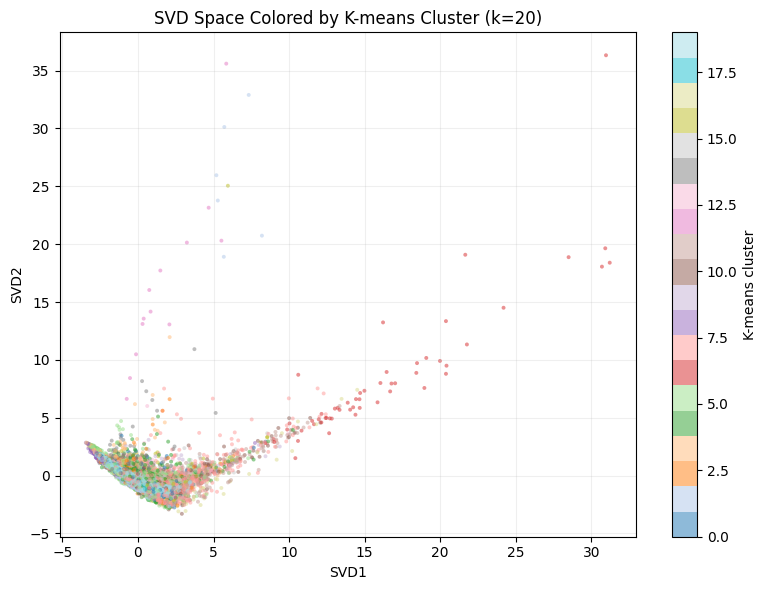

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_cluster[:, 0], X_cluster[:, 1], c=df["cluster"], cmap="tab20", s=8, alpha=0.5, linewidths=0)
fig.colorbar(scatter, ax=ax, label="K-means cluster")
ax.set_title(f"SVD Space Colored by K-means Cluster (k={best_k})")
ax.set_xlabel("SVD1")
ax.set_ylabel("SVD2")
ax.grid(alpha=0.2)
save_current_plot(WEEK7_PLOT_DIR / "kmeans_svd_cluster_scatter.png")
plt.show()


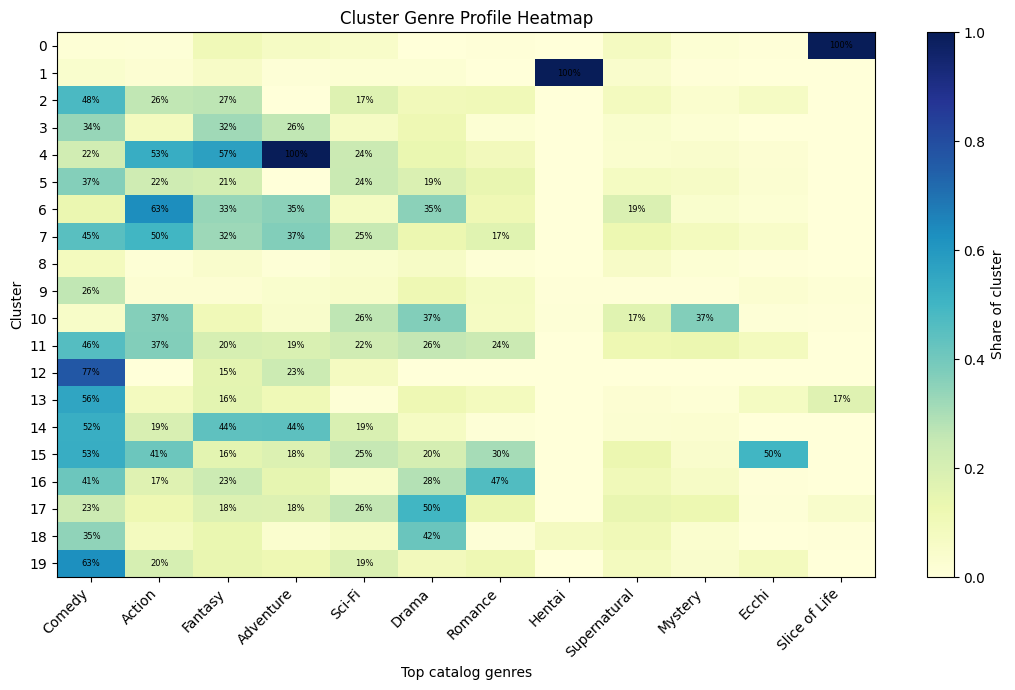

In [13]:
top_genres = Counter()
for value in df["genres"]:
    top_genres.update(split_pipe(value))
top_genres = [name for name, _count in top_genres.most_common(12)]

cluster_ids = sorted(df["cluster"].unique())
heat = []
for cluster_id in cluster_ids:
    subset = df[df["cluster"] == cluster_id]
    denominator = max(len(subset), 1)
    counts = Counter()
    for value in subset["genres"]:
        counts.update(split_pipe(value))
    heat.append([counts[genre] / denominator for genre in top_genres])
heat = np.array(heat)

fig, ax = plt.subplots(figsize=(11, max(5, len(cluster_ids) * 0.35)))
im = ax.imshow(heat, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(top_genres)), labels=top_genres, rotation=45, ha="right")
ax.set_yticks(range(len(cluster_ids)), labels=cluster_ids)
ax.set_xlabel("Top catalog genres")
ax.set_ylabel("Cluster")
ax.set_title("Cluster Genre Profile Heatmap")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if heat[i, j] >= 0.15:
            ax.text(j, i, f"{heat[i, j]:.0%}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, label="Share of cluster")
save_current_plot(WEEK7_PLOT_DIR / "cluster_genre_profile_heatmap.png")
plt.show()


## Validation Table

    Silhouette and inertia summarize geometry, not domain truth. Cluster profiles and examples are needed to decide whether the segmentation is useful for recommendation and discovery.

In [14]:
validation_table = pd.concat([
    kmeans_results.assign(eps=np.nan, min_samples=np.nan, clusters=lambda x: x["k"], noise_pct=0.0)[["method", "k", "eps", "min_samples", "clusters", "silhouette", "inertia", "davies_bouldin", "noise_pct"]],
    dbscan_results.rename(columns={"silhouette_non_noise": "silhouette"}).assign(k=np.nan, inertia=np.nan, davies_bouldin=np.nan)[["method", "k", "eps", "min_samples", "clusters", "silhouette", "inertia", "davies_bouldin", "noise_pct"]],
    optics_results.rename(columns={"silhouette_non_noise": "silhouette"}).assign(k=np.nan, eps=np.nan, inertia=np.nan, davies_bouldin=np.nan)[["method", "k", "eps", "min_samples", "clusters", "silhouette", "inertia", "davies_bouldin", "noise_pct"]],
], ignore_index=True)
validation_table


,method,k,eps,min_samples,clusters,silhouette,inertia,davies_bouldin,noise_pct
0,KMeans,4.0,NaN,NaN,4,0.057001,780172.816469,3.932817,0.000000
1,KMeans,6.0,NaN,NaN,6,0.028989,748353.918886,3.699124,0.000000
2,KMeans,8.0,NaN,NaN,8,0.050449,716880.551969,3.350319,0.000000
3,KMeans,10.0,NaN,NaN,10,0.051253,685516.674716,2.890972,0.000000
4,KMeans,12.0,NaN,NaN,12,0.073493,664545.431854,2.840132,0.000000
5,KMeans,14.0,NaN,NaN,14,0.057036,641766.324255,2.592509,0.000000
6,KMeans,16.0,NaN,NaN,16,0.082976,618528.079284,2.478919,0.000000
7,KMeans,18.0,NaN,NaN,18,0.075784,597438.585938,2.422624,0.000000
8,KMeans,20.0,NaN,NaN,20,0.104147,576681.686488,2.389221,0.000000
9,DBSCAN,NaN,1.8,10.0,9,0.350517,NaN,NaN,90.633333


## Failure Analysis

    K-means will tend to separate by popularity, format, and broad genre because those dimensions explain substantial variance. It may over-simplify hybrid shows. DBSCAN and OPTICS can identify noise and niche titles, but both are sensitive to density assumptions and may label many sparse or unusual titles as outliers.

    What should not be overclaimed:

    - A cluster is not a genre taxonomy.
    - A high silhouette score does not prove useful recommendations.
    - t-SNE-like visual islands would not be cluster validation.
    - Adult tags and rare tags can distort clusters if not handled carefully.


## Defense Preparation

    - We clustered the SVD-compressed mixed representation because it includes numeric, categorical, and text/tag signals.
    - K-means assumes spherical clusters and assigns every title; DBSCAN and OPTICS assume density and can mark noise.
    - Parameter sweeps show sensitivity instead of one hand-picked model.
    - Cluster profiles connect validation metrics to anime-domain meaning.
    - Weakest clusters are likely small mixed-format or sparse-metadata clusters.
